In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import datetime as dt
np.random.seed(42)

In [2]:
#Téléchargement des données NVIDIA
ticker = "NVDA"
nvda = yf.download(ticker,
                   start="2015-01-01",
                   end=dt.datetime.now())['Close']
nvda.head()

/tmp/ipython-input-405/2332791549.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nvda = yf.download(ticker,
[*********************100%***********************]  1 of 1 completed


Ticker,NVDA
Date,
2015-01-02,0.483011
2015-01-05,0.474853
2015-01-06,0.460457
2015-01-07,0.459257
2015-01-08,0.476533


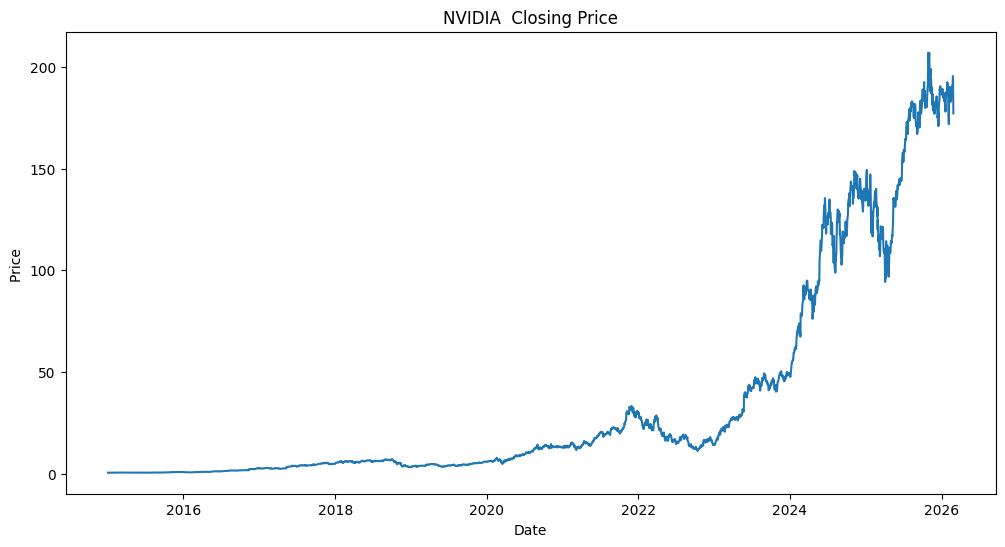

In [3]:
plt.figure(figsize=(12,6))
plt.plot(nvda)
plt.title("NVIDIA  Closing Price")
plt.xlabel("Date")
plt.ylabel("Price ")
plt.show()

On observe une tendance croissante du prix au cours du temps, ce qui suggère la présence d’une tendance déterministe ou stochastique, et donc une possible non-stationnarité du processus. On prend alors les log-rendements afin de supprimer cette tendance et d’obtenir une série potentiellement stationnaire.

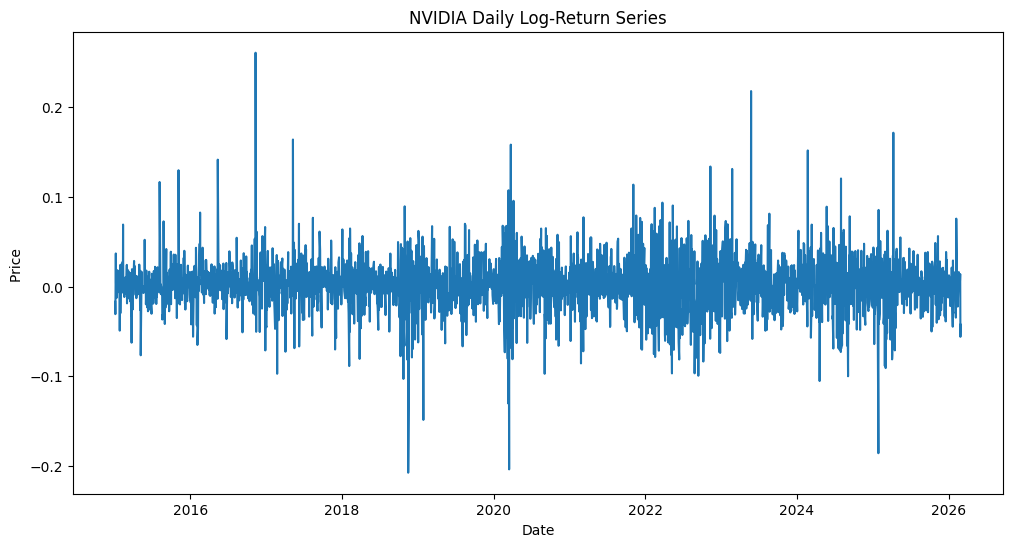

In [4]:
log_returns=np.log(nvda/nvda.shift(1)).dropna()
plt.figure(figsize=(12,6))
plt.plot(log_returns)
plt.title("NVIDIA Daily Log-Return Series")
plt.xlabel("Date")
plt.ylabel("Price ")
plt.show()

La série semble a priori stationnaire : elle fluctue autour d’une moyenne proche de zéro, sans tendance apparente, ce qui rappelle le comportement d’un bruit blanc. On observe néanmoins quelques clusters de volatilité que l’on traitera dans une autre partie. Testons formellement la stationnarité à l’aide d’un test ADF

Hypothèses du test

**H₀** : La série possède une racine unitaire → elle est non stationnaire.

**H₁** : La série est stationnaire.


In [5]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(log_returns)

print("ADF Statistic:", result[0])
print(f"p-value: {result[1]:.10e}")



ADF Statistic: -18.94515626829396
p-value: 0.0000000000e+00


Étant donné que la p-value est largement inférieure au seuil de 5 %, nous rejetons l’hypothèse nulle de racine unitaire. Cela confirme que la série ne présente pas de tendance stochastique et qu’elle est stationnaire en moyenne.

Afin de déterminer les ordres du modèle ARIMA, il est nécessaire d’analyser les corrélogrammes de la série stationnaire.

L’étude de la fonction d’autocorrélation (ACF) et de la fonction d’autocorrélation partielle (PACF) permet d’identifier la structure dynamique de la série et d’orienter le choix des paramètres
𝑝
p (ordre autorégressif) et
𝑞
q (ordre moyenne mobile).

En particulier, un « cut-off » de la PACF suggère un modèle AR(p), tandis qu’un « cut-off » de l’ACF suggère un modèle MA(q). Si les deux fonctions décroissent progressivement, un modèle ARMA(p,q) peut être envisagé.

<Figure size 1200x400 with 0 Axes>

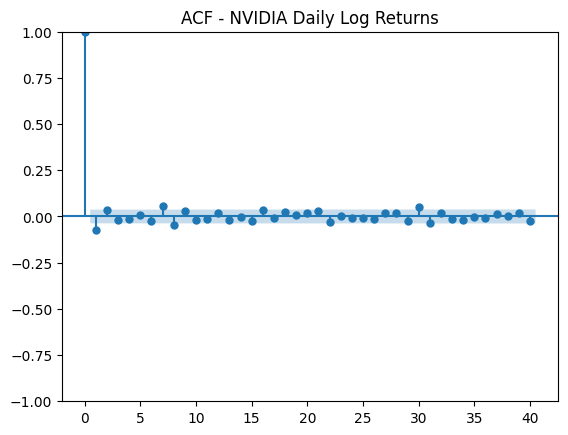

<Figure size 1200x400 with 0 Axes>

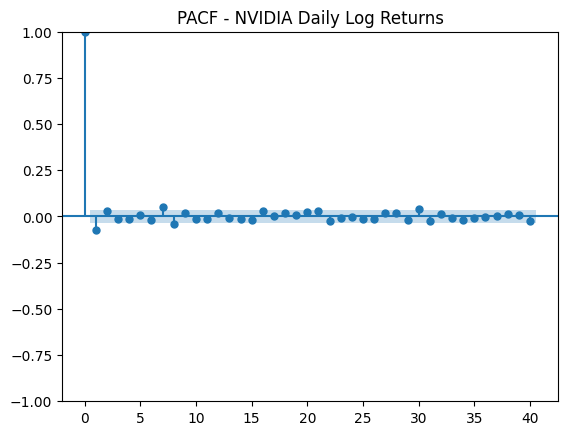

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plot_acf(log_returns, lags=40)
plt.title("ACF - NVIDIA Daily Log Returns")
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(log_returns, lags=40, method="ywm")
plt.title("PACF - NVIDIA Daily Log Returns")
plt.show()

Les corrélogrammes ACF et PACF ne révèlent aucune autocorrélation significative. La série des log-rendements peut donc être modélisée par un ARMA(0,0), c’est-à-dire un bruit blanc.

Cela est cohérent avec la théorie financière selon laquelle les rendements suivent un processus imprévisible, tandis que les prix suivent une marche aléatoire.
Le modèle ARMA(0,0) implique que les rendements suivent un bruit blanc. La meilleure prévision conditionnelle du rendement futur est donc nulle. En revanche, la présence de clusters de volatilité suggère que la variance conditionnelle pourrait être modélisée via un processus GARCH.

In [7]:
from statsmodels.tsa.arima.model import ARIMA

y = log_returns.dropna()

model_00 = ARIMA(y, order=(0,0,0))   # ARMA(0,0)
fit_00 = model_00.fit()

print(fit_00.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                   NVDA   No. Observations:                 2804
Model:                          ARIMA   Log Likelihood                5819.012
Date:                Sun, 01 Mar 2026   AIC                         -11634.025
Time:                        09:58:23   BIC                         -11622.147
Sample:                             0   HQIC                        -11629.738
                               - 2804                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0021      0.001      3.660      0.000       0.001       0.003
sigma2         0.0009   1.17e-05     79.020      0.000       0.001       0.001
Ljung-Box (L1) (Q):                  14.14   Jarque-

Bien que le modèle ARIMA(0,0,0) capture correctement la moyenne des rendements (constante significative avec une p-value égale à 0.000), l’analyse des critères d’information et des tests diagnostiques permet d’affiner l’évaluation du modèle.

L’AIC (-11634.023) et le BIC (-11622.146) indiquent qu’il s’agit d’un modèle parcimonieux. Toutefois, ces critères ne garantissent pas à eux seuls une bonne spécification dynamique, ce qui justifie l’analyse approfondie des résidus.

Le test de Ljung-Box présente une p-value égale à 0.00. Nous rejetons donc l’hypothèse nulle d’absence d’autocorrélation des résidus, ce qui suggère qu’une légère dépendance temporelle persiste.

Le test de Jarque-Bera affiche également une p-value égale à 0.00. Nous rejetons ainsi l’hypothèse de normalité des résidus. La kurtosis élevée (9.92) met en évidence la présence de queues épaisses, caractéristique typique des rendements financiers.

Enfin, le test d’hétéroscédasticité indique une p-value égale à 0.00. Nous rejetons donc l’hypothèse d’homoscedasticité, ce qui signifie que la variance des résidus varie dans le temps.

Ainsi, bien que la dynamique de la moyenne soit correctement capturée, la variance conditionnelle présente une structure persistante. La présence d’hétéroscédasticité conditionnelle et de clusters de volatilité justifie l’introduction d’un modèle de type GARCH afin de modéliser la dynamique de la variance conditionnelle.



Bien que l’analyse des corrélogrammes (ACF et PACF) fournisse une première indication sur les ordres potentiels du modèle, cette méthode reste essentiellement heuristique et visuelle.

Afin d’obtenir une sélection plus rigoureuse et objective des paramètres \( (p,d,q) \), nous utilisons une procédure automatique de type **auto-ARIMA**. Cette méthode compare plusieurs spécifications possibles et sélectionne le modèle optimal selon un critère d’information, tel que l’AIC ou le BIC.

Contrairement à l’interprétation visuelle des corrélogrammes, l’auto-ARIMA repose sur une optimisation formelle du compromis entre qualité d’ajustement et parcimonie du modèle.

Cette approche permet ainsi de déterminer l’ordre optimal du modèle de manière plus robuste et statistiquement fondée.

In [8]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 34.7 MB/s eta 0:00:00


In [9]:
 from pmdarima import auto_arima

In [10]:
model_auto = auto_arima(
    log_returns,
    seasonal=False,
    stepwise=True,
    trace=True
)

print(model_auto.summary())

best_order = model_auto.order
print(f"Auto ARIMA found that the best order is {best_order}")

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-11631.113, Time=1.83 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-11622.578, Time=0.32 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-11632.754, Time=0.22 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-11631.864, Time=1.14 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-11634.640, Time=0.62 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=-11632.765, Time=2.16 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-11632.680, Time=2.60 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-11633.301, Time=0.59 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=-11630.775, Time=0.71 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=-11647.027, Time=1.18 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-11646.198, Time=0.35 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=-11645.431, Time=0.54 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=-11644.977, Time=1.62 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-11646.877, Time=2.04 sec
 ARIM

Le modèle ARIMA(2,0,0) est sélectionné par le critère AIC et améliore l’ajustement par rapport au modèle ARIMA(0,0,0). Les coefficients autorégressifs sont significatifs, ce qui indique la présence d’une faible dépendance temporelle à court terme dans les rendements.

Le test de Ljung-Box ne rejette plus l’hypothèse d’absence d’autocorrélation (p-value = 0.97), ce qui suggère que la dynamique de la moyenne est désormais correctement capturée.

Toutefois, la persistance d’hétéroscédasticité (p-value = 0.00) confirme la nécessité d’un modèle de type GARCH pour modéliser la variance conditionnelle.


Afin d’évaluer la capacité prédictive du modèle, nous divisons la série des log-rendements en deux sous-échantillons : un échantillon d’entraînement (*train set*) et un échantillon de test (*test set*).

Nous retenons 80 % des observations pour l’estimation du modèle (phase d’apprentissage) et 20 % des observations restantes pour l’évaluation hors échantillon.

L’échantillon d’entraînement est utilisé pour estimer les paramètres du modèle ARIMA, tandis que l’échantillon de test permet d’évaluer la performance prédictive du modèle sur des données non observées lors de l’estimation.

Cette approche permet de limiter le risque de sur-apprentissage (*overfitting*) et d’obtenir une évaluation plus réaliste des capacités de prévision du modèle.

In [11]:


y = log_returns.dropna()

train_size = int(len(y) * 0.8)

train = y[:train_size]
test = y[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 2243
Test size: 561



Le modèle est ajusté uniquement sur les données d’entraînement.  


In [12]:


p, d, q = best_order

model = ARIMA(train, order=(p, d, q))
model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                   NVDA   No. Observations:                 2243
Model:                 ARIMA(2, 0, 0)   Log Likelihood                4674.152
Date:                Sun, 01 Mar 2026   AIC                          -9340.304
Time:                        09:59:28   BIC                          -9317.442
Sample:                             0   HQIC                         -9331.958
                               - 2243                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0020      0.001      3.235      0.001       0.001       0.003
ar.L1         -0.0640      0.015     -4.258      0.000      -0.093      -0.035
ar.L2          0.0193      0.017      1.125      0.2

## Interprétation rapide – ARIMA(2,0,0)

L’intercept est positif et significatif (p-value = 0.001), ce qui indique un rendement moyen journalier positif.

Le coefficient AR(1) est significatif (p-value = 0.000), suggérant une légère dépendance à court terme. En revanche, le coefficient AR(2) n’est pas significatif (p-value = 0.261), son apport semble donc limité.

Le test de Ljung-Box (p-value = 0.99) indique l’absence d’autocorrélation résiduelle : la dynamique de la moyenne est correctement capturée.

Cependant, les tests de normalité (Jarque-Bera, p-value = 0.00) et d’hétéroscédasticité (p-value = 0.00) montrent que les résidus ne sont ni normalement distribués ni homoskedastiques.

La modélisation de la volatilité via un GARCH est donc pertinente.

Nous utilisons le modèle estimé sur l’échantillon d’entraînement pour générer des prévisions sur la période de test, sur un horizon égal au nombre d’observations hors échantillon.

In [13]:
forecast = model_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


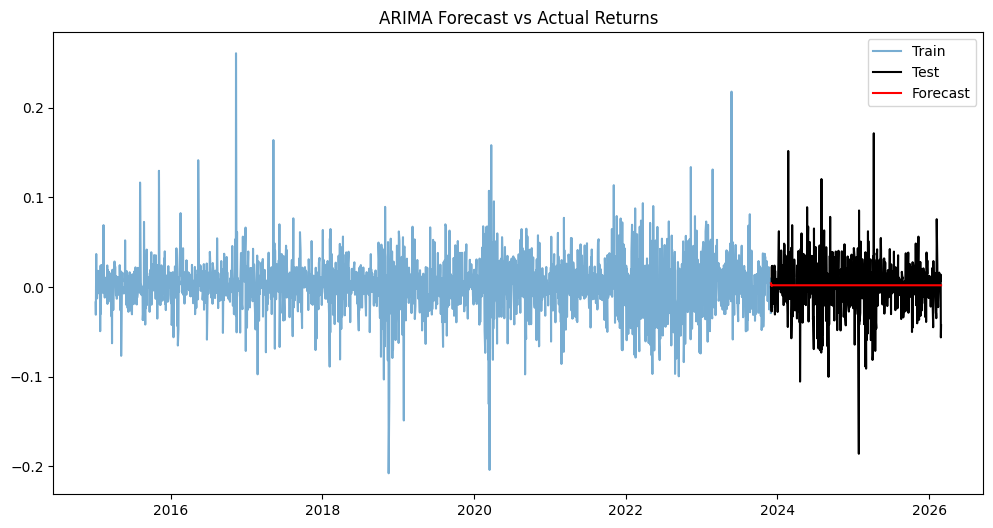

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(train.index, train, label="Train", alpha=0.6)
plt.plot(test.index, test, label="Test", color="black")
plt.plot(test.index, forecast, label="Forecast", color="red")

plt.title("ARIMA Forecast vs Actual Returns")
plt.legend()
plt.show()

Le graphique compare les rendements observés sur l’échantillon de test (en noir) aux prévisions générées par le modèle ARIMA (en rouge), estimé sur l’échantillon d’entraînement.

Les prévisions apparaissent quasiment constantes et proches de la moyenne estimée du processus. Le modèle ne parvient pas à anticiper les fortes fluctuations observées dans la période de test.

Ce résultat est cohérent avec la théorie financière selon laquelle les rendements sont difficilement prévisibles en moyenne. Le modèle ARIMA capture correctement la dynamique moyenne, mais ne permet pas de modéliser les variations importantes de volatilité.

La persistance de clusters de volatilité et l’hétéroscédasticité observée dans les résidus justifient alors l’introduction d’un modèle de type GARCH afin de modéliser explicitement la dynamique de la variance conditionnelle.

In [16]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 32.3 MB/s eta 0:00:00


In [17]:
from arch import arch_model
import itertools

y = 100 * log_returns.dropna()

best_aic = float("inf")
best_order = None

for p, q in itertools.product(range(1,3), range(1,3)):
    try:
        model = arch_model(y, vol='GARCH', p=p, q=q)
        res = model.fit(disp='off')

        if res.aic < best_aic:
            best_aic = res.aic
            best_order = (p, q)
    except:
        continue

print("Best GARCH order:", best_order)
print("Best AIC:", best_aic)

Best GARCH order: (2, 2)
Best AIC: 13882.111517329686


In [19]:
am = arch_model(
    train,
    mean="AR", lags=2,
    vol="GARCH", p=2, q=2,
    dist="normal"
)

res = am.fit(disp="off")
print(res.summary())

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0009069. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


                           AR - GARCH Model Results                           
Dep. Variable:                   NVDA   R-squared:                       0.002
Mean Model:                        AR   Adj. R-squared:                  0.001
Vol Model:                      GARCH   Log-Likelihood:                4784.13
Distribution:                  Normal   AIC:                          -9552.26
Method:            Maximum Likelihood   BIC:                          -9506.54
                                        No. Observations:                 2241
Date:                Sun, Mar 01 2026   Df Residuals:                     2238
Time:                        10:09:08   Df Model:                            3
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
Const      2.8480e-03  6.185e-04      4.605  4.133e-06 



Le modèle estimé combine une dynamique autorégressive d’ordre 2 pour la moyenne et un processus GARCH(2,2) pour la variance conditionnelle.

La constante est positive et statistiquement significative (p-value < 0.01), indiquant un rendement moyen journalier positif.  
En revanche, les coefficients AR(1) et AR(2) ne sont pas statistiquement significatifs aux seuils usuels. Cela suggère que la dynamique autorégressive de la moyenne est faible, voire négligeable.

Le faible R² (≈ 0.002) est cohérent avec la littérature financière : les rendements sont généralement difficilement prévisibles en moyenne.


Les coefficients ARCH (α₁ et α₂) sont positifs et significatifs, ce qui indique que les chocs passés influencent la volatilité actuelle.  
Les coefficients GARCH (β₁ et β₂) sont également positifs, traduisant une persistance de la volatilité dans le temps.

La somme des coefficients (α₁ + α₂ + β₁ + β₂ ≈ 0.90) est proche de 1, ce qui met en évidence une forte persistance de la volatilité, phénomène classique sur les marchés financiers.  
Toutefois, cette somme restant inférieure à 1, le processus demeure stationnaire en variance.



Les résultats confirment que les rendements sont peu prévisibles en moyenne, mais que leur volatilité présente une dynamique persistante et conditionnelle.  
Le modèle GARCH permet ainsi de capturer les clusters de volatilité observés empiriquement, conformément à la théorie financière moderne.

In [20]:
h = len(test)

fcast = res.forecast(horizon=h, reindex=False)


var_forecast = fcast.variance.iloc[-1].values
vol_forecast = np.sqrt(var_forecast)

In [21]:
vol_forecast = pd.Series(vol_forecast, index=test.index, name="ForecastVol")

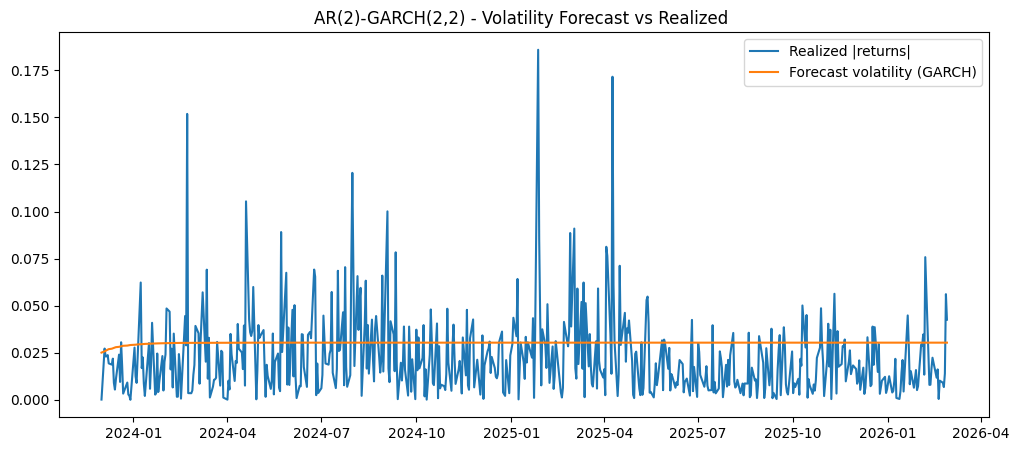

In [23]:
realized = test.abs()
plt.figure(figsize=(12,5))
plt.plot(realized.index, realized, label="Realized |returns| ")
plt.plot(vol_forecast.index, vol_forecast, label="Forecast volatility (GARCH)")
plt.title("AR(2)-GARCH(2,2) - Volatility Forecast vs Realized ")
plt.legend()
plt.show()

In [24]:
mean_forecast = fcast.mean.iloc[-1].values
mean_forecast = pd.Series(mean_forecast, index=test.index, name="ForecastMean")

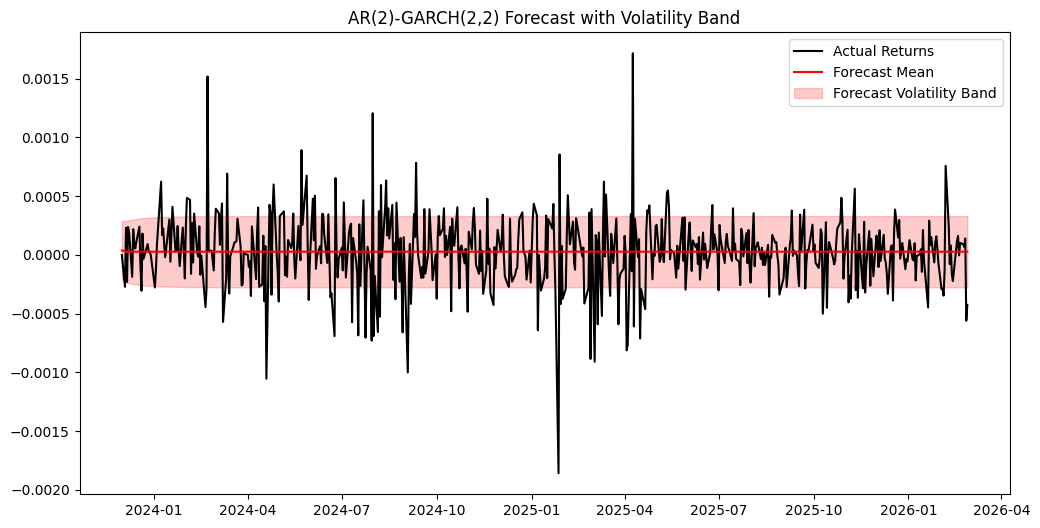

In [25]:
plt.figure(figsize=(12,6))

plt.plot(test.index, test/100, color="black", label="Actual Returns")
plt.plot(mean_forecast.index, mean_forecast/100,
         color="red", label="Forecast Mean")

plt.fill_between(
    test.index,
    (mean_forecast - vol_forecast)/100,
    (mean_forecast + vol_forecast)/100,
    color="red",
    alpha=0.2,
    label="Forecast Volatility Band"
)

plt.title("AR(2)-GARCH(2,2) Forecast with Volatility Band")
plt.legend()
plt.show()

Le modèle AR-GARCH parvient à capturer la dynamique générale du marché, en particulier la structure moyenne des rendements ainsi que l’évolution de la volatilité conditionnelle dans le temps.

La bande de volatilité reflète correctement les périodes plus calmes et les phases de tension, ce qui montre que le modèle intègre bien la persistance de la volatilité.

Cependant, certains mouvements extrêmes dépassent les intervalles prévus. Ces écarts correspondent à des chocs rares ou à des événements exceptionnels que le modèle, fondé sur une distribution conditionnelle standard, ne parvient pas à anticiper pleinement.

Ainsi, le modèle reproduit la tendance globale du marché et les clusters de volatilité, mais reste limité face aux événements extrêmes.